# Imports & Setup

In [76]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from torch import nn
import matplotlib.pyplot as plt
import os
import numpy as np
import imageio
from collections import OrderedDict
from typing import Dict, Callable, List
from IPython.display import display, Markdown
from transformers import LogitsProcessor, LogitsProcessorList, GenerationConfig

In [4]:
# torch.cuda.empty_cache()

In [107]:
class GenerationStep:
    def __init__(self, scores: torch.FloatTensor, preceding_token: str):
        self.scores = scores
        self.preceding_token = preceding_token

    def __repr__(self):
        return \
            f"------------------- Scores -------------------\n{self.scores}\n" + \
            f"----------------- Prec.Token -----------------\n{self.preceding_token}\n" + \
            f"\n"

class GenerationChain:
    def __init__(self, chain: List[GenerationStep] = []):
        self.chain = chain

    def add_generation_step(self, new_step: GenerationStep):
        self.chain.append(new_step)

    def __repr__(self):
        return f"{[print(generation_step) for generation_step in self.chain]}"

generation_chain = GenerationChain()

class CustomLogitsProcessor(LogitsProcessor):
    def __init__(self, preceding_token: str):
        self.preceding_token = preceding_token

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
        step = GenerationStep(scores=scores, preceding_token=self.preceding_token)
        generation_chain.chain.append(step)

        return scores

In [108]:
class Model:
    def __init__(self, model_name: str, device: str):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.device = device
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            dtype='auto',
            device_map=self.device
        )

    def __repr__(self):
        return \
            f"------------------- Model -------------------\n{self.model.__class__.__name__}\n" + \
            f"----------------- Tokenizer -----------------\n{self.tokenizer.__class__.__name__}\n" + \
            f"------------------- Device ------------------\n{self.device}\n"

    def prepare_inputs(self, prompt: str):
        prompt = "Solve this equation for x: 2x + 5 = 17. Please reason step by step, and put your final answer within \boxed{}."
        messages = [
            {"role": "user", "content": prompt}
        ]
        tokenized_chat = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=True
        )
        inputs = self.tokenizer([tokenized_chat], return_tensors="pt").to(self.device)

        return inputs

    def generate(
            self,
            inputs,
            max_new_tokens: int = 256,
            temperature: float = 0.6,
            top_p: float = 0.95,
            top_k: int = 20,
            custom_logits_processors: list = None
        ):
        if not custom_logits_processors:
            custom_logits_processors = []

        custom_generation_config = GenerationConfig(
            max_new_tokens=max_new_tokens,
            # temperature=temperature,
            # top_p=top_p,
            # top_k=top_k,
            output_scores=True,
            output_logits=True, # Set output_logits to True
            return_dict_in_generate=True # Return a dictionary with scores and logits
        )

        with torch.inference_mode():
            generation_output = self.model.generate(
                **inputs,
                generation_config=custom_generation_config,
                logits_processor=LogitsProcessorList(custom_logits_processors),
            )

        logits = generation_output.logits
        scores = generation_output.scores
        output_ids = generation_output.sequences[0][len(inputs.input_ids[0]):].tolist()
        response = self.tokenizer.decode(output_ids, skip_special_tokens=True)

        return (response, scores, logits)

In [ ]:
model_name = "Qwen/Qwen3-4B"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Model(model_name, device)
model

In [109]:
inputs = model.prepare_inputs("The capital of France is")

In [111]:
custom_logits_processor = CustomLogitsProcessor(preceding_token=inputs.input_ids[0][0].detach().cpu())
response, scores, logits = model.generate(
    inputs,
    max_new_tokens=5,
    custom_logits_processors=[custom_logits_processor]
)

In [112]:
generation_chain.chain

[------------------- Scores -------------------
 tensor([[-11.6250, -11.5000, -10.8125,  ...,  12.8750,  12.8750,  12.8750]],
        device='cuda:0')
 ----------------- Prec.Token -----------------
 151644
 ,
 ------------------- Scores -------------------
 tensor([[2.5000, 3.7969, 1.3828,  ..., 6.0312, 6.0312, 6.0312]],
        device='cuda:0')
 ----------------- Prec.Token -----------------
 151644
 ,
 ------------------- Scores -------------------
 tensor([[-4.6997e-03,  9.6875e+00,  2.9375e+00,  ..., -3.4219e+00,
          -3.4219e+00, -3.4219e+00]], device='cuda:0')
 ----------------- Prec.Token -----------------
 151644
 ,
 ------------------- Scores -------------------
 tensor([[12.6250,  2.1250,  0.6602,  ..., -6.5312, -6.5312, -6.5312]],
        device='cuda:0')
 ----------------- Prec.Token -----------------
 151644
 ,
 ------------------- Scores -------------------
 tensor([[ 3.8438,  2.1094, -2.5938,  ..., -5.5000, -5.5000, -5.5000]],
        device='cuda:0')
 ------------

In [113]:
response

'<think>\nOkay, so'

In [114]:
logits

(tensor([[-11.6250, -11.5000, -10.8125,  ...,  12.8750,  12.8750,  12.8750]],
        device='cuda:0'),
 tensor([[2.5000, 3.7969, 1.3828,  ..., 6.0312, 6.0312, 6.0312]],
        device='cuda:0'),
 tensor([[-4.6997e-03,  9.6875e+00,  2.9375e+00,  ..., -3.4219e+00,
          -3.4219e+00, -3.4219e+00]], device='cuda:0'),
 tensor([[12.6250,  2.1250,  0.6602,  ..., -6.5312, -6.5312, -6.5312]],
        device='cuda:0'),
 tensor([[ 3.8438,  2.1094, -2.5938,  ..., -5.5000, -5.5000, -5.5000]],
        device='cuda:0'))

In [115]:
scores

(tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'))

In [116]:
logits[0].detach().cpu().numpy().max(), torch.nn.functional.softmax(logits[0].detach().cpu(), dim=1).max()

(np.float32(34.5), tensor(1.0000))

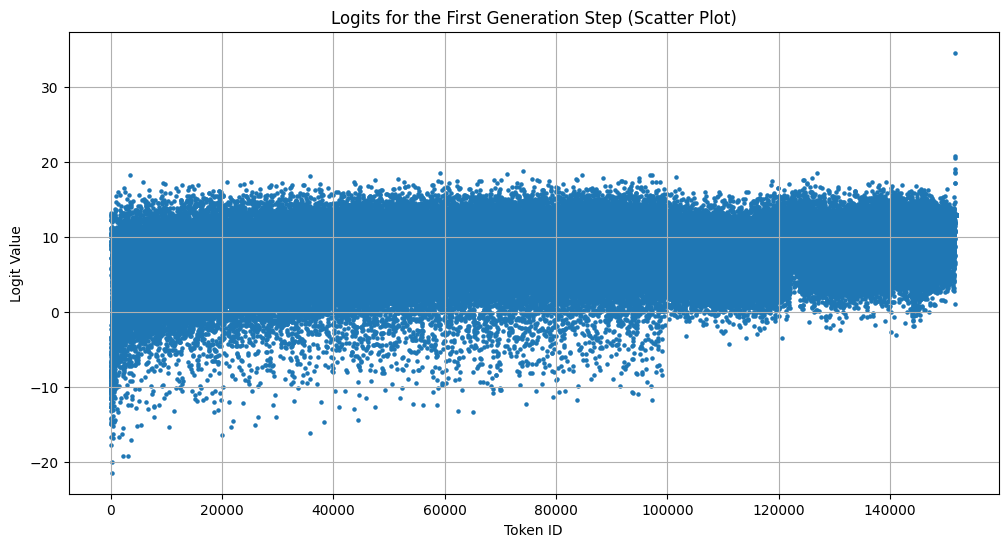

In [64]:
import matplotlib.pyplot as plt

# Access the first tensor in the logits tuple
first_logits = logits[0].detach().cpu().numpy()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(range(len(first_logits.flatten())), first_logits.flatten(), s=5) # s is marker size
plt.title('Logits for the First Generation Step (Scatter Plot)')
plt.xlabel('Token ID')
plt.ylabel('Logit Value')
plt.grid(True)
plt.show()

In [67]:
first_scores.min(), first_scores.max()

(np.float32(-inf), np.float32(57.5))

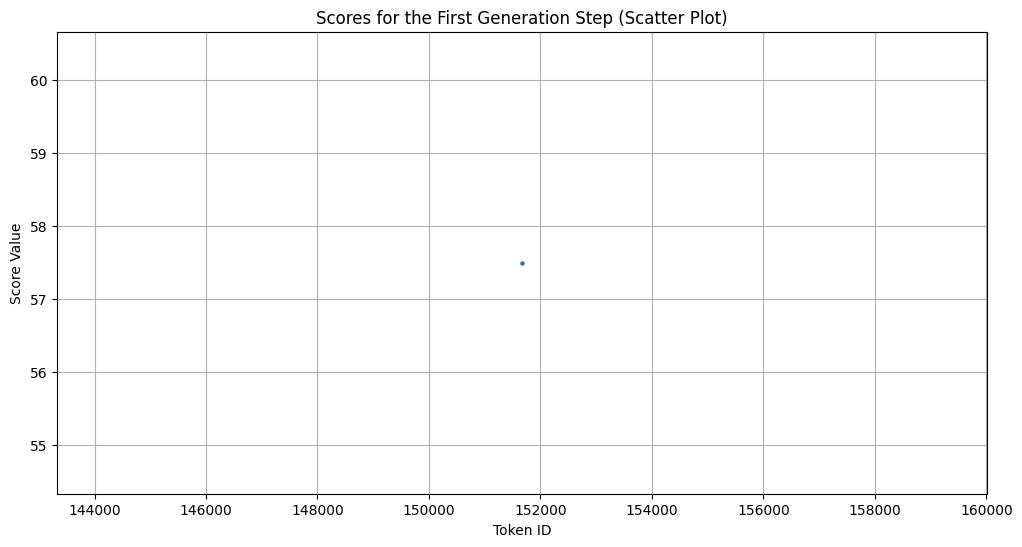

In [65]:
import matplotlib.pyplot as plt

# Access the first tensor in the scores tuple
first_scores = scores[0].detach().cpu().numpy()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(range(len(first_scores.flatten())), first_scores.flatten(), s=5) # s is marker size
plt.title('Scores for the First Generation Step (Scatter Plot)')
plt.xlabel('Token ID')
plt.ylabel('Score Value')
plt.grid(True)
plt.show()